In [1]:
import pandas as pd
import numpy as np
import glob
import os
import re 

v_rel_defined = 50e5 # relative velocity in cm/s

#folder with the files to analyze
folder_path = r"C:\Users\Zuza\Desktop\praktyki cbk 2026\H1He0el\*.dat"

#list of files that suits the pattern
file_list = glob.glob(folder_path)

print(f"Nr of files found: {len(file_list)}\n")
print(f"Finding files with (approximate) relative velocity: {v_rel_defined} cm/s (50 km/s)...\n")

best_lower_v = 0
best_lower_file = None

best_upper_v = 10e8
best_upper_file = None


# main loop - analyze each file 
for path in file_list:
    file_name = os.path.basename(path)
    
    # open file in read mode and extract the 9th line
    with open(path, 'r') as file:
        lines = file.readlines() 
        
        # line 9 -> line 8 in python notation
        row_9 = lines[8]
        
        # takes 1st number found in the line and convert it to float
        liczby_w_linii = re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", row_9)
        v_file = float(liczby_w_linii[0])
        
    # lower limit logic (<= 5 mln)
    if v_file <= v_rel_defined: #checks if the velocity in the file is less than or equal to the defined relative velocity
        if v_file > best_lower_v:
            best_lower_v = v_file
            best_lower_file = file_name
            
    # upper limit logic (>= 5 mln)
    if v_file >= v_rel_defined:
        if v_file < best_upper_v:
            best_upper_v = v_file
            best_upper_file = file_name

# relative error calculations and printing results

if best_lower_file:
    lower_error = abs(best_lower_v - v_rel_defined) / v_rel_defined * 100
    print("--- THE BEST LOWER LIMIT ---")
    print(f"File: {best_lower_file}")
    print(f"Velocity: {best_lower_v} cm/s")
    print(f"Relative error: {lower_error:.4f}%\n")
else:
    print("No file found with velocity less than or equal to 50 km/s.\n")

if best_upper_file:
    upper_error = abs(best_upper_v - v_rel_defined) / v_rel_defined * 100
    print("--- THE BEST UPPER LIMIT ---")
    print(f"File: {best_upper_file}")
    print(f"Velocity: {best_upper_v} cm/s")
    print(f"Relative error: {upper_error:.4f}%\n")
else:
    print("No file found with velocity greater than or equal to 50 km/s.")


if lower_error < upper_error:
    print(f"The best file: {best_lower_file} (Relative error: {lower_error:.2f}%)\n")
    best_file = best_lower_file
else:
    print(f"The best file: {best_upper_file} (Relative error: {upper_error:.2f}%)\n")
    best_file = best_upper_file



Nr of files found: 661

Finding files with (approximate) relative velocity: 5000000.0 cm/s (50 km/s)...

--- THE BEST LOWER LIMIT ---
File: dcsH1He0el_1000log10e_+1000.dat
Velocity: 4896814.9622 cm/s
Relative error: 2.0637%

--- THE BEST UPPER LIMIT ---
File: dcsH1He0el_1000log10e_+1050.dat
Velocity: 5186969.4902 cm/s
Relative error: 3.7394%

The best file: dcsH1He0el_1000log10e_+1000.dat (Relative error: 2.06%)



      angle  diff_sigma  weight_factor
0  0.000008   14.963135       0.000020
1  0.000041   78.818221       0.000046
2  0.000100  193.431293       0.000072
3  0.000185  357.668879       0.000098
4  0.000296  568.454347       0.000125


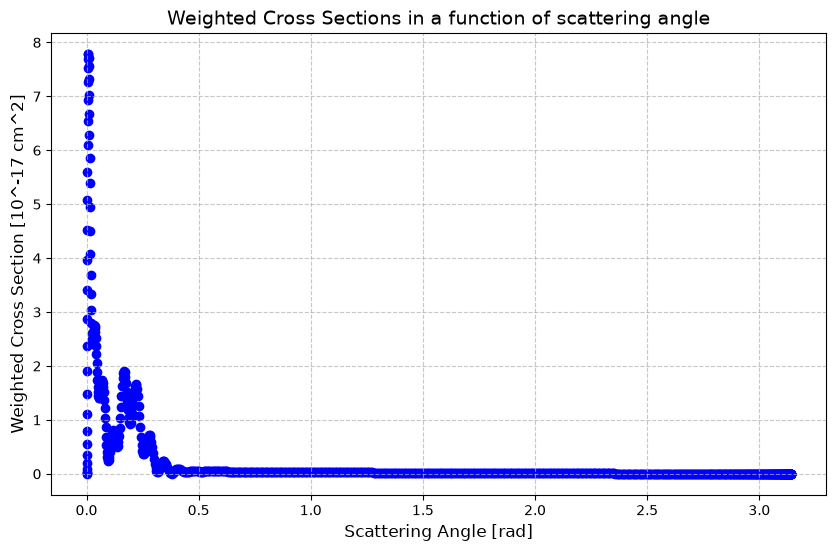

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dcsH1He0el_1000log10e_+1000.dat', 
                 skiprows=18, 
                 sep=r'\s+', 
                 names=['angle', 'diff_sigma', 'weight_factor'])

# (just checking)
print(df.head())


df['wynik'] = df['diff_sigma'] * df['weight_factor'] * 2.8002852056


plt.figure(figsize=(10, 6))

plt.scatter(df['angle'], df['wynik'], color='blue')

plt.title('Weighted Cross Sections in a function of scattering angle', fontsize=14)
plt.xlabel('Scattering Angle [rad]', fontsize=12)
plt.ylabel('Weighted Cross Section [10^-17 cm^2]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

start of simulation for 500 particles...
simulation done


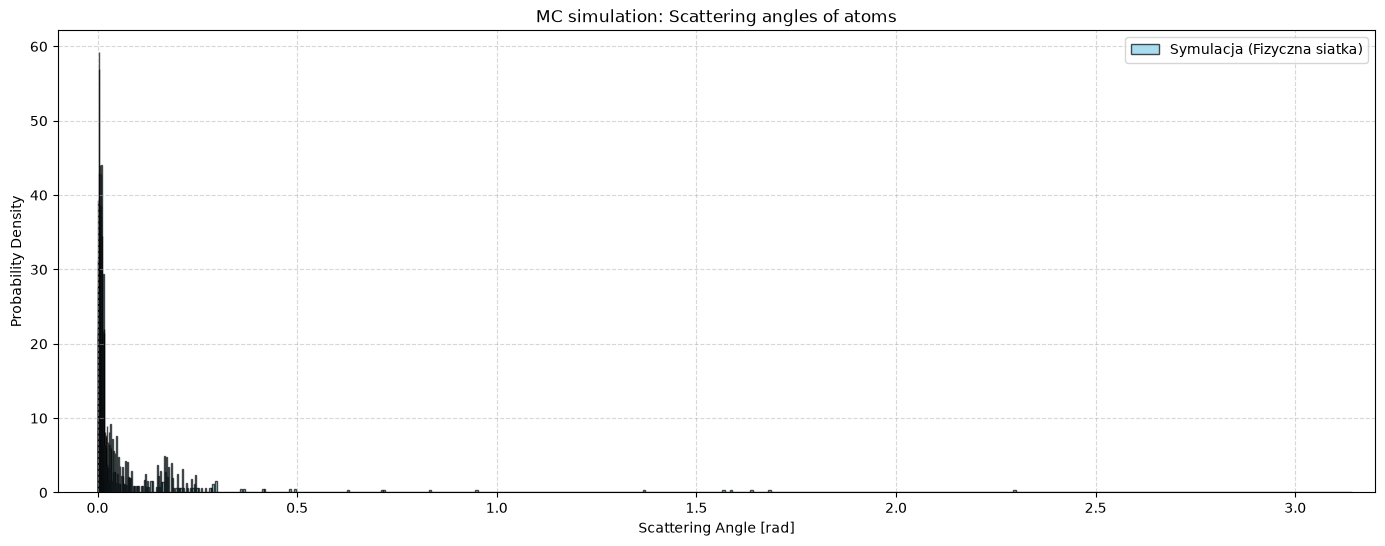

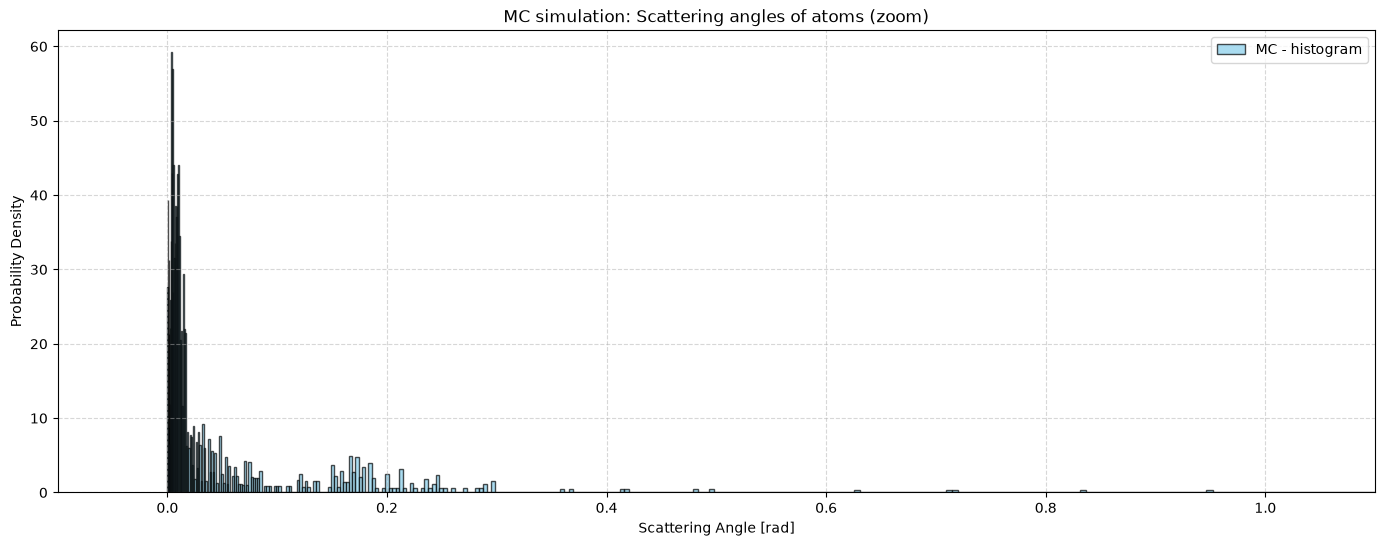

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#wczytywanie 3 kolumn z pliku
df = pd.read_csv('dcsH1He0el_1000log10e_+1000.dat', 
                 skiprows=18, 
                 sep=r'\s+', 
                 names=['Angle', 'DCS', 'Weight'])
#sprawdzenie kątów, czy uporządkowane rosnąco
df = df.sort_values(by='Angle').reset_index(drop=True)

#probability for each angle
df['Raw_Prob'] = df['DCS'] * df['Weight']

# normalization of probabilities
sum_probabillity = df['Raw_Prob'].sum()
df['Probability'] = df['Raw_Prob'] / sum_probabillity


#bins definition
# Upewniamy się, że kąty są posortowane rosnąco (bardzo ważne dla granic!)



# monte carlo
N_0 = 500 # number of collisions

print(f"start of simulation for {N_0} particles...")

drawed_angles = np.random.choice(a=df['Angle'], #draws values from the 'Angle' column
                                   size=N_0, 
                                   p=df['Probability']) #gives the probability for each angle

print("simulation done")

######### angles ###########
angles = df['Angle'].values

#boundaries in the middle of the list
inner_boundaries = angles[:-1] + np.diff(angles) / 2.0

left_boundary = [angles[0] - (angles[1] - angles[0]) / 2.0] #first term in the list 
right_boundary = [angles[-1] + (angles[-1] - angles[-2]) / 2.0] #last term in the list

# one list from the smaller parts
physical_boundaries = np.concatenate((left_boundary, inner_boundaries, right_boundary))

#scattering angle cannot be negatuve 
physical_boundaries[physical_boundaries < 0] = 0




plt.figure(figsize=(17, 6))

plt.hist(drawed_angles, bins=physical_boundaries, density=True, 
         color='skyblue', edgecolor='black', alpha=0.7, 
         label='Symulacja (Fizyczna siatka)')

theoretical_curve = df['Probability'] / df['Weight']

#plt.plot(df['Angle'], theoretical_curve, color='red', linewidth=2, label='normalized DCS - theory')

plt.title('MC simulation: Scattering angles of atoms')
plt.xlabel('Scattering Angle [rad]')
plt.xlim(-0.1, 3.2)  # Zakres osi X od 0 do 3.14 radianów (0 do 180 stopni)
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

##################

plt.figure(figsize=(17, 6))

plt.hist(drawed_angles, bins=physical_boundaries, density=True, color='skyblue', edgecolor='black', alpha=0.7, label='MC - histogram')
#plt.plot(df['Angle'], theoretical_curve, color='red', linewidth=2, label='normalized DCS - theory')

plt.title('MC simulation: Scattering angles of atoms (zoom)')
plt.xlabel('Scattering Angle [rad]')
plt.xlim(-0.1, 1.1)  
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [3]:
import pandas as pd
import numpy as np
import glob
import os
import re 

v_rel_defined = 50e6 # relative velocity in cm/s

#folder with the files to analyze
folder_path = r"C:\Users\Zuza\Desktop\praktyki cbk 2026\H1He0el\*.dat"

#list of files that suits the pattern
file_list = glob.glob(folder_path)

print(f"Nr of files found: {len(file_list)}\n")
print(f"Finding files with (approximate) relative velocity: {v_rel_defined} cm/s (50 km/s)...\n")

best_lower_v = 0
best_lower_file = None

best_upper_v = 10e8
best_upper_file = None


# main loop - analyze each file 
for path in file_list:
    file_name = os.path.basename(path)
    
    # open file in read mode and extract the 9th line
    with open(path, 'r') as file:
        lines = file.readlines() 
        
        # line 9 -> line 8 in python notation
        row_9 = lines[8]
        
        # takes 1st number found in the line and convert it to float
        liczby_w_linii = re.findall(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", row_9)
        v_file = float(liczby_w_linii[0])
        
    # lower limit logic (<= 5 mln)
    if v_file <= v_rel_defined: #checks if the velocity in the file is less than or equal to the defined relative velocity
        if v_file > best_lower_v:
            best_lower_v = v_file
            best_lower_file = file_name
            
    # upper limit logic (>= 5 mln)
    if v_file >= v_rel_defined:
        if v_file < best_upper_v:
            best_upper_v = v_file
            best_upper_file = file_name

# relative error calculations and printing results

if best_lower_file:
    lower_error = abs(best_lower_v - v_rel_defined) / v_rel_defined * 100
    print("--- THE BEST LOWER LIMIT ---")
    print(f"File: {best_lower_file}")
    print(f"Velocity: {best_lower_v} cm/s")
    print(f"Relative error: {lower_error:.4f}%\n")
else:
    print("No file found with velocity less than or equal to 50 km/s.\n")

if best_upper_file:
    upper_error = abs(best_upper_v - v_rel_defined) / v_rel_defined * 100
    print("--- THE BEST UPPER LIMIT ---")
    print(f"File: {best_upper_file}")
    print(f"Velocity: {best_upper_v} cm/s")
    print(f"Relative error: {upper_error:.4f}%\n")
else:
    print("No file found with velocity greater than or equal to 50 km/s.")


if lower_error < upper_error:
    print(f"The best file: {best_lower_file} (Relative error: {lower_error:.2f}%)\n")
    best_file = best_lower_file
else:
    print(f"The best file: {best_upper_file} (Relative error: {upper_error:.2f}%)\n")
    best_file = best_upper_file


Nr of files found: 661

Finding files with (approximate) relative velocity: 50000000.0 cm/s (50 km/s)...

--- THE BEST LOWER LIMIT ---
File: dcsH1He0el_1000log10e_+3000.dat
Velocity: 48968149.622 cm/s
Relative error: 2.0637%

--- THE BEST UPPER LIMIT ---
File: dcsH1He0el_1000log10e_+3100.dat
Velocity: 54943167.549 cm/s
Relative error: 9.8863%

The best file: dcsH1He0el_1000log10e_+3000.dat (Relative error: 2.06%)



      angle   diff_sigma  weight_factor
0  0.000008   108.797941       0.000020
1  0.000041   570.257227       0.000046
2  0.000100  1366.453637       0.000072
3  0.000185  2393.537825       0.000098
4  0.000296  3541.202715       0.000125


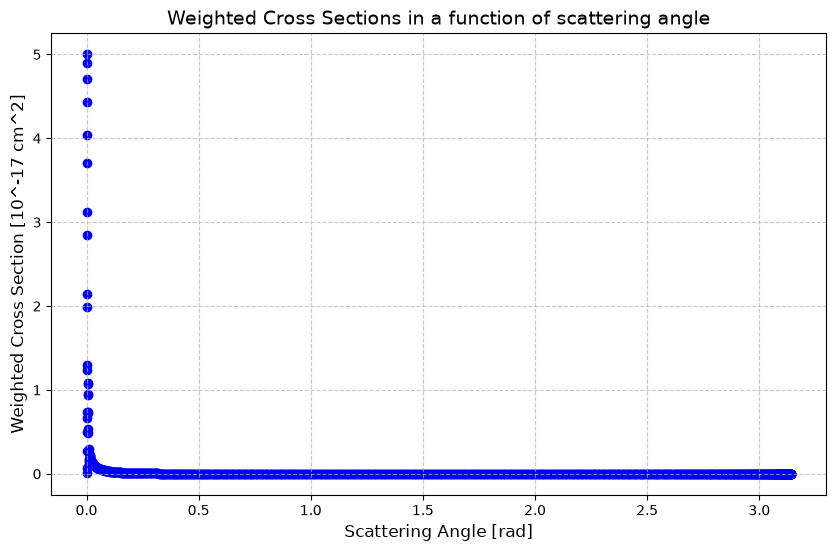

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dcsH1He0el_1000log10e_+3000.dat', 
                 skiprows=18, 
                 sep=r'\s+', 
                 names=['angle', 'diff_sigma', 'weight_factor'])

# (just checking)
print(df.head())


df['wynik'] = df['diff_sigma'] * df['weight_factor'] * 2.8002852056


plt.figure(figsize=(10, 6))

plt.scatter(df['angle'], df['wynik'], color='blue')

plt.title('Weighted Cross Sections in a function of scattering angle', fontsize=14)
plt.xlabel('Scattering Angle [rad]', fontsize=12)
plt.ylabel('Weighted Cross Section [10^-17 cm^2]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

start of simulation for 500 particles...
simulation done


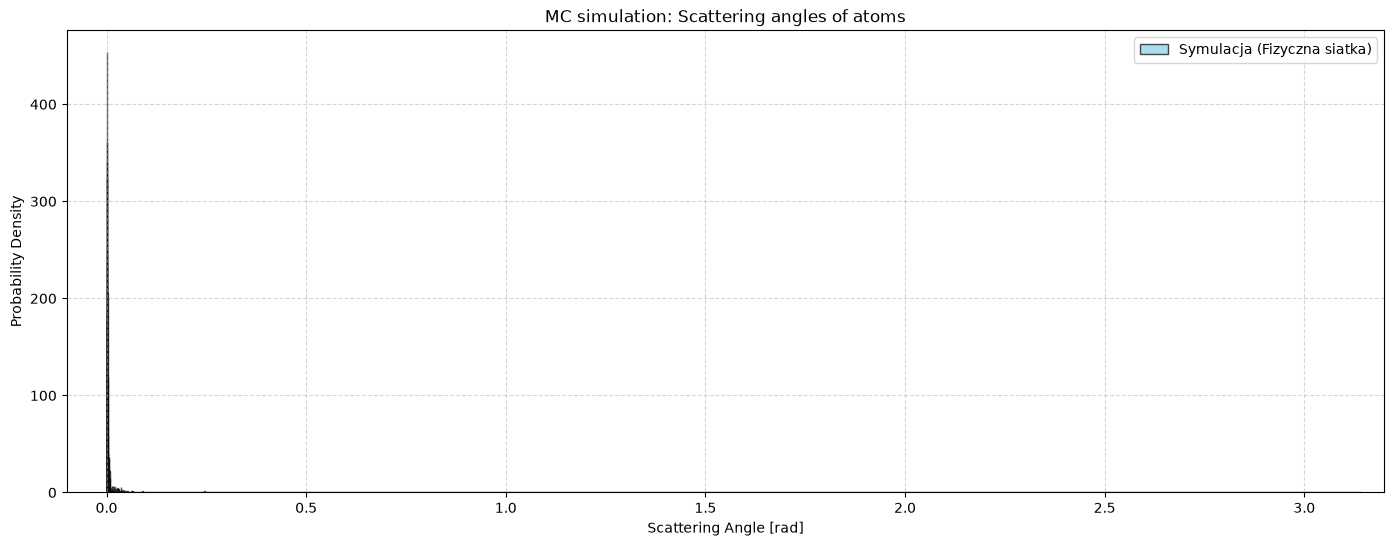

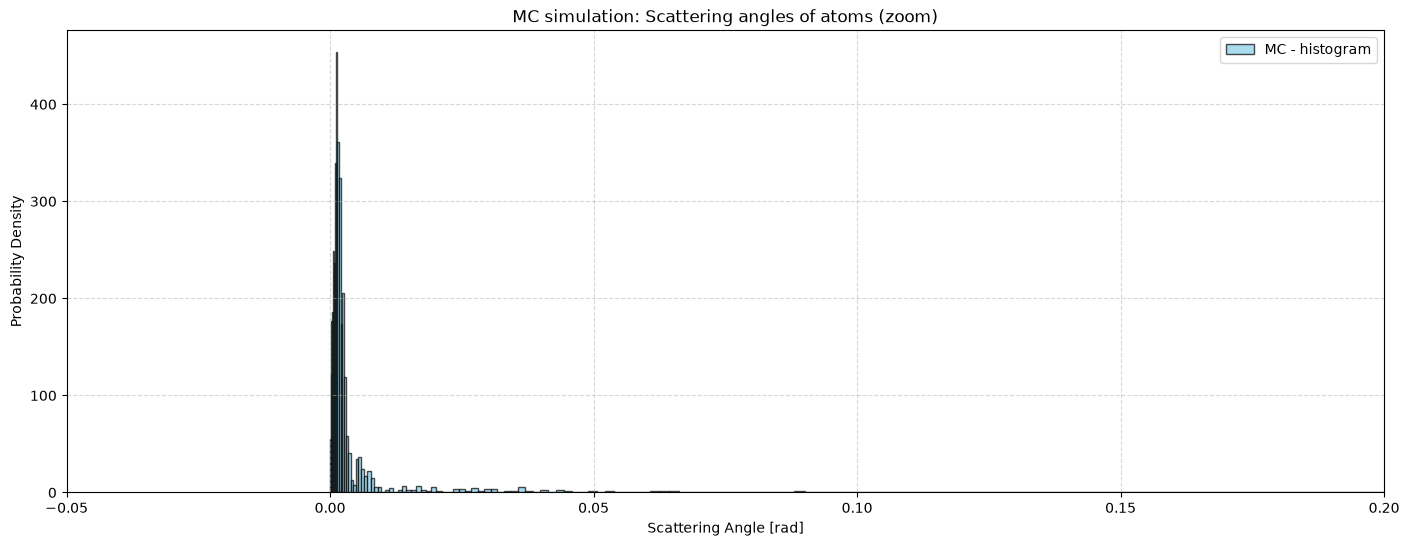

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#wczytywanie 3 kolumn z pliku
df = pd.read_csv('dcsH1He0el_1000log10e_+3000.dat', 
                 skiprows=18, 
                 sep=r'\s+', 
                 names=['Angle', 'DCS', 'Weight'])
#sprawdzenie kątów, czy uporządkowane rosnąco
df = df.sort_values(by='Angle').reset_index(drop=True)

#probability for each angle
df['Raw_Prob'] = df['DCS'] * df['Weight']

# normalization of probabilities
sum_probabillity = df['Raw_Prob'].sum()
df['Probability'] = df['Raw_Prob'] / sum_probabillity


#bins definition
# Upewniamy się, że kąty są posortowane rosnąco (bardzo ważne dla granic!)



# monte carlo
N_0 = 500 # number of collisions

print(f"start of simulation for {N_0} particles...")

drawed_angles = np.random.choice(a=df['Angle'], #draws values from the 'Angle' column
                                   size=N_0, 
                                   p=df['Probability']) #gives the probability for each angle

print("simulation done")

######### angles ###########
angles = df['Angle'].values

#boundaries in the middle of the list
inner_boundaries = angles[:-1] + np.diff(angles) / 2.0

left_boundary = [angles[0] - (angles[1] - angles[0]) / 2.0] #first term in the list 
right_boundary = [angles[-1] + (angles[-1] - angles[-2]) / 2.0] #last term in the list

# one list from the smaller parts
physical_boundaries = np.concatenate((left_boundary, inner_boundaries, right_boundary))

#scattering angle cannot be negatuve 
physical_boundaries[physical_boundaries < 0] = 0


plt.figure(figsize=(17, 6))

plt.hist(drawed_angles, bins=physical_boundaries, density=True, 
         color='skyblue', edgecolor='black', alpha=0.7, 
         label='Symulacja (Fizyczna siatka)')

theoretical_curve = df['Probability'] / df['Weight']

#plt.plot(df['Angle'], theoretical_curve, color='red', linewidth=2, label='normalized DCS - theory')

plt.title('MC simulation: Scattering angles of atoms')
plt.xlabel('Scattering Angle [rad]')
plt.xlim(-0.1, 3.2)  # Zakres osi X od 0 do 3.14 radianów (0 do 180 stopni)
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

##################

plt.figure(figsize=(17, 6))

plt.hist(drawed_angles, bins=physical_boundaries, density=True, color='skyblue', edgecolor='black', alpha=0.7, label='MC - histogram')
#plt.plot(df['Angle'], theoretical_curve, color='red', linewidth=2, label='normalized DCS - theory')

plt.title('MC simulation: Scattering angles of atoms (zoom)')
plt.xlabel('Scattering Angle [rad]')
plt.xlim(-0.05, 0.2)  
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()